employee attrition prediction - xgboost
---------------------------------------------
train accuracy: 1.0
test accuracy: 0.65
---------------------------------------------
              precision    recall  f1-score   support

      stayed       0.77      0.79      0.78        47
        left       0.17      0.15      0.16        13

    accuracy                           0.65        60
   macro avg       0.47      0.47      0.47        60
weighted avg       0.64      0.65      0.64        60



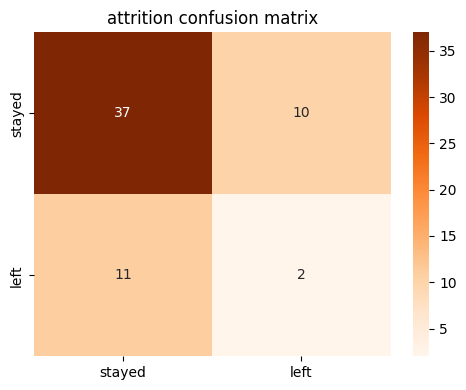

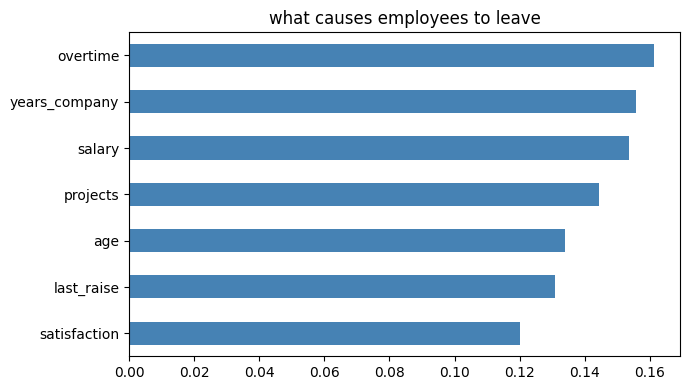

employee prediction: will leave!
confidence: 69.4 %


In [5]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 300

data = {
    "age":           np.random.randint(22, 58, n),
    "salary":        np.random.randint(25000, 150000, n),
    "years_company": np.random.randint(0, 20, n),
    "satisfaction":  np.random.randint(1, 5, n),
    "last_raise":    np.random.randint(0, 30, n),
    "overtime":      np.random.choice([0, 1], n),
    "projects":      np.random.randint(1, 8, n),
    "left":          np.random.choice([0, 1], n, p=[0.7, 0.3])
}

df = pd.DataFrame(data)
x = df.drop("left", axis=1)
y = df["left"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = xgb.XGBClassifier(n_estimators=200,
                           max_depth=4,
                           learning_rate=0.1,
                           random_state=42,
                           eval_metric="logloss",
                           verbosity=0)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("employee attrition prediction - xgboost")
print("-" * 45)
print("train accuracy:", round(model.score(x_train, y_train), 3))
print("test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("-" * 45)
print(classification_report(y_test, y_pred,
      target_names=["stayed", "left"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["stayed", "left"],
            yticklabels=["stayed", "left"])
plt.title("attrition confusion matrix")
plt.tight_layout()
plt.show()

importance = pd.Series(
    model.feature_importances_,
    index=x.columns
).sort_values()

importance.plot(kind="barh", color="steelblue", figsize=(7, 4))
plt.title("what causes employees to leave")
plt.tight_layout()
plt.show()

new_emp = [[28, 35000, 2, 2, 5, 1, 6]]
result = model.predict(new_emp)
prob = model.predict_proba(new_emp)
print("employee prediction:",
      "will leave!" if result[0] == 1 else "will stay")
print("confidence:", round(max(prob[0]) * 100, 1), "%")